
## FX Short Strategy — Research & Signal Notebook

**Purpose:** Research, validate, and operate a momentum-based FX short strategy on GBPCHF.
The strategy shorts GBPCHF when a rolling OLS slope confirms a sustained downtrend, with configurable
entry confirmation (consecutive days), grace-period exits, and optional rise-kill stops.

---

### Two-phase OOS workflow
Before committing live capital, run the sweep and frozen-run cells in this order:

1. **Holdout sweep** (`SWEEP_MODE = "holdout"`): sweep only the pre-holdout series; the last
   `OOS_HOLDOUT_MONTHS` remain unseen.
2. **OOS validate** (`EVAL_OOS = True`): frozen-run cell loads the holdout sweep CSV and evaluates
   the best params on the held-out period. Check against pre-defined acceptance thresholds.
3. **If OOS passes**: re-run the sweep with `SWEEP_MODE = "full_series"` to get regime-current params
   that include the most recent data. The prior OOS result is not invalidated — it was run on genuinely
   unseen data.
4. **Production signal**: set `EVAL_OOS = False` in the frozen-run cell; the cell evaluates on the
   full (or selected-sweep) window and prints the daily actionable flag.

---

### Module dependencies
| Module | Role |
|---|---|
| `functions1.py` | I/O layer: data fetch, cache, URL building, OHLC cleaning, runtime config |
| `functions2.py` | Series utilities (`standardize_fx_daily_index`, `trim_series`, `plotter`) + portfolio/risk-matrix analytics (not used here) |
| `fxshort_gates.py` | Strategy core: gate logic, sweep, trade analysis, entry-delay sensitivity, plot |
| `scripts/sample_window_sweep.py` | Rolling/expanding window generation |
| `config.py` | Data source params, cache directory, API keys |

> **Note on naming:** `functions1` / `functions2` are opaque names. `functions1` is the I/O layer;
> `functions2` bundles general series utilities with portfolio-risk analytics (unrelated to this notebook).
> Candidate rename: `functions1` → `data_io.py`, `functions2` → `series_utils.py` + `portfolio.py`.


### Run Setup

In [1]:
import os
import sys
import json
import pathlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import importlib
import fxshort_gates
import config
import functions2
import functions1

importlib.reload(fxshort_gates)
importlib.reload(functions2)
importlib.reload(functions1)

# Runtime config
RUN_MODE = "research"  # "research" or "production"
ticker = "GBPCHF"
window_start = "2022-08-04"
window_end = None

# Explicit cost model (all modeled costs are always included).
CARRY_ANN = 0.053
FEE_PER_TRADE = 0.00016  # round-trip fee for ~20k notional when fee is ~1.60 per side
SLIPPAGE_PER_TRADE = 0.00002
OTHER_DAILY_FEE_ANN = 0.0

runtime_params, run_meta = functions1.build_runtime_config(
    dict(config.params),
    run_mode=RUN_MODE,
    ticker=ticker,
    window_start=window_start,
    window_end=window_end,
)
MAX_AGE = runtime_params["max_age"]
FORCE_REFRESH = bool(run_meta["force_refresh"])

print('runtime_params:', runtime_params)
print("run_id:", run_meta["run_id"])

print("mode:", run_meta["run_mode"])

print("datasource:", runtime_params["datasource"])

print("max_age:", runtime_params["max_age"], "force_refresh:", FORCE_REFRESH)

print("cost model:", {
    "carry_ann": CARRY_ANN,
    "fee_per_trade": FEE_PER_TRADE,
    "slippage_per_trade": SLIPPAGE_PER_TRADE,
    "other_daily_fee_ann": OTHER_DAILY_FEE_ANN,
})

runtime_params: {'start': '2022-08-04', 'end': '20260312', 'datasource': 'stooq', 'max_age': 22.0}
run_id: 13bdaf7cd813
mode: research
datasource: stooq
max_age: 22.0 force_refresh: False
cost model: {'carry_ann': 0.053, 'fee_per_trade': 0.00016, 'slippage_per_trade': 2e-05, 'other_daily_fee_ann': 0.0}


### Fetch And Prepare Series

In [2]:
df = functions1.fetch_csv_robust(
    ticker=ticker,
    params=runtime_params,
    force_refresh=FORCE_REFRESH,
 )
s = functions1.sort_cols(df)
s = functions2.standardize_fx_daily_index(s)
s = functions2.trim_series(s, window_start, window_end)

print(ticker)
print('series starts:', s.index[0].date())
print('series ends:', s.index[-1].date())
print("rows:", len(s))

GBPCHF - incremental update 2026-03-11 -> 2026-03-12
gap days: -2404
required start: 2022-08-04 
data start: 2016-01-04
sort_cols: ohlc not set. True only needed for ATR calculations for vol stops. Defaulting to False
GBPCHF
series starts: 2022-08-04
series ends: 2026-03-11
rows: 931


### Cache Health

In [3]:
cache_status = functions1.print_cache_status(ticker)

CACHE STATUS [WARN] GBPCHF
cache meta path: /Users/alexwebb/laptop_coding/risk_matrix/cache/GBPCHF.meta.json
last_update_mode: incremental
last_update_utc: 2026-03-12T17:12:05Z
last_full_refresh_utc: 2026-03-11T14:02:49Z


### Smoke Checks

In [4]:
# Lightweight deterministic smoke checks
assert runtime_params["max_age"] == MAX_AGE
assert isinstance(s, pd.Series) and len(s) > 50

toy = pd.Series(
    [100.0, 99.5, 99.0, 98.8, 98.6, 98.7, 98.9, 98.4, 98.1, 97.9],
    index=pd.date_range("2024-01-01", periods=10, freq="B"),
    dtype=float,
)
toy_gate = fxshort_gates.fxshort_gate(
    toy,
    slope_window=3,
    consec=1,
    shift_for_signal=True,
    require_carry=False,
    min_run_days=1,
    slope_source="log_price",
)
assert toy_gate.index.equals(toy.index)
assert toy_gate.dtype == bool
print("smoke checks passed")

smoke checks passed


### Run gate with Frozen params

In [5]:

# --- Run gate with frozen parameters ---
# This cell loads the best parameters from the latest sweep results (if available),
# applies acceptance thresholds, and sets the evaluation window to match the sweep window.
# The frozen parameters are then used to run the gate logic and analyze trades.

# Toggle: Evaluate out-of-sample (OOS) results using a window outside the selected sweep window.
EVAL_OOS = True  # Set to True to run OOS evaluation
# OOS window logic: by default, use the period immediately after the sweep window.
OOS_WINDOW_MONTHS = 6  # Number of months for OOS window (can adjust)
# Minimum row count for a valid OOS window (~2 months of business days).
# Fewer rows produces highly unreliable stats — warn rather than silently proceed.
OOS_MIN_ROWS = 40

print(ticker)

# Toggle: load params from latest saved sweep artifact if available.
USE_LATEST_SAVED_SWEEP_PARAMS = True

# Toggle: if selected sweep row has a source window, evaluate frozen run on that same window.
USE_SOURCE_WINDOW_FROM_SELECTED_ROW = True

# Acceptance thresholds for selecting a production candidate from saved sweep rows.
SELECTION_THRESHOLDS = {
    "min_net_expectancy_per_trade": 0.0003,
    "min_trades": 20,
    "min_win_rate": 0.45,
    "min_payoff_ratio": 1.15,     # avg_win / abs(avg_loss)
    "max_draw_trade_pct_floor": -0.025,
}

# Manual fallback if no compatible saved sweep candidate passes thresholds.
frozen_cfg = {
    "carry_ann": CARRY_ANN,
    "buffer20": 0.00,
    "slope_window": 15,
    "consec": 2,
    "slope_entry_threshold": -1e-4,
    "slope_exit_threshold": 0.000,
    "grace_days": 2,
    "require_carry": True,
    "consec_rises_kill": 0,
    "rise_kill_pct": 0.01,
    "rise_kill_window": 3,
    "min_run_days": 3,
    "slope_source": "log_price",
}

frozen_params_source = "manual fallback"
selected_window_start = None
selected_window_end = None
# The maximum window_end seen across ALL sweep windows in the CSV — this is the true
# training data boundary. The OOS period must start after this date, not just after
# the selected row's window_end, because global ranking across all windows means all
# window data influenced parameter selection (even windows whose params were discarded).
max_sweep_window_end = None

# If sweep params are available, load them and set the evaluation window to match the sweep window.
if USE_LATEST_SAVED_SWEEP_PARAMS:
    latest_files = sorted(
        pathlib.Path(".").glob("sweep_results_*.csv"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    selected_row = None
    selected_file = None
    selected_rank_col = None

    for csv_path in latest_files:
        try:
            saved = pd.read_csv(csv_path)
        except Exception:
            continue
        if saved.empty:
            continue
        if "ticker" in saved.columns:
            saved = saved[saved["ticker"].astype(str) == str(ticker)]
            if saved.empty:
                continue

        rank_col = "net_expectancy_per_trade" if "net_expectancy_per_trade" in saved.columns else "total_pct_return"
        if rank_col not in saved.columns:
            continue

        ranked = saved.sort_values(rank_col, ascending=False, kind="mergesort").reset_index(drop=True)

        def _passes_thresholds(row: pd.Series) -> bool:
            net_exp = float(row.get("net_expectancy_per_trade", np.nan))
            trades_n = float(row.get("trades", np.nan))
            win_r = float(row.get("win_rate", np.nan))
            avg_win = float(row.get("avg_win", np.nan))
            avg_loss = float(row.get("avg_loss", np.nan))
            draw_trade = float(row.get("max_draw_trade_pct", np.nan))

            # Apply acceptance thresholds for sweep candidate selection.
            if np.isnan(net_exp) or net_exp < SELECTION_THRESHOLDS["min_net_expectancy_per_trade"]:
                return False
            if np.isnan(trades_n) or trades_n < SELECTION_THRESHOLDS["min_trades"]:
                return False
            if np.isnan(win_r) or win_r < SELECTION_THRESHOLDS["min_win_rate"]:
                return False
            if np.isnan(draw_trade) or draw_trade < SELECTION_THRESHOLDS["max_draw_trade_pct_floor"]:
                return False

            if np.isnan(avg_win) or np.isnan(avg_loss) or avg_loss >= 0:
                return False
            payoff_ratio = avg_win / abs(avg_loss)
            if payoff_ratio < SELECTION_THRESHOLDS["min_payoff_ratio"]:
                return False

            return True

        passing = ranked[ranked.apply(_passes_thresholds, axis=1)]
        if len(passing) == 0:
            continue

        selected_row = passing.iloc[0]
        selected_file = csv_path.name
        selected_rank_col = rank_col

        # Record the latest window_end across ALL windows in this CSV (for this ticker).
        # This is the true boundary of what the sweep "saw" during training.
        if "window_end" in saved.columns:
            max_sweep_window_end = pd.Timestamp(pd.to_datetime(saved["window_end"]).max())

        break

    if selected_row is not None:
        # Update frozen config with best sweep params.
        frozen_cfg.update({
            "carry_ann": float(selected_row.get("carry_ann", CARRY_ANN)),
            "buffer20": float(selected_row.get("buffer20", frozen_cfg["buffer20"])),
            "slope_window": int(selected_row.get("slope_window", frozen_cfg["slope_window"])),
            "consec": int(selected_row.get("consec", frozen_cfg["consec"])),
            "slope_entry_threshold": float(selected_row.get("slope_entry_thr", frozen_cfg["slope_entry_threshold"])),
            "slope_exit_threshold": float(selected_row.get("slope_exit_thr", frozen_cfg["slope_exit_threshold"])),
            "grace_days": int(selected_row.get("grace_days", frozen_cfg["grace_days"])),
            "require_carry": bool(selected_row.get("require_carry", frozen_cfg["require_carry"])),
            "consec_rises_kill": int(selected_row.get("consec_rises_kill", frozen_cfg["consec_rises_kill"])),
            "rise_kill_pct": (
                float(selected_row["rise_kill_pct"])
                if pd.notna(selected_row.get("rise_kill_pct", np.nan))
                else None
            ),
            "rise_kill_window": (
                int(selected_row["rise_kill_window"])
                if pd.notna(selected_row.get("rise_kill_window", np.nan))
                else None
            ),
            "slope_source": str(selected_row.get("slope_source", frozen_cfg["slope_source"])),
        })
        # Set the sweep window boundaries for evaluation.
        if "window_start" in selected_row.index and pd.notna(selected_row.get("window_start", np.nan)):
            selected_window_start = pd.Timestamp(selected_row["window_start"] )
        if "window_end" in selected_row.index and pd.notna(selected_row.get("window_end", np.nan)):
            selected_window_end = pd.Timestamp(selected_row["window_end"] )
        frozen_params_source = f"loaded from {selected_file} with thresholds ({selected_rank_col})"

print("Best param discovery window:", selected_window_start, "to", selected_window_end)
print("Max sweep window_end (true training boundary):", max_sweep_window_end)

# --- OOS window selection logic ---
if EVAL_OOS and selected_window_end is not None:
    # Use the maximum window_end across ALL sweep windows as the OOS cutoff.
    # This is correct because every sweep window contributed to the global ranking
    # that selected our parameters — using only the selected row's window_end would
    # understate how much of the series was "seen" during training.
    oos_cutoff = max_sweep_window_end if max_sweep_window_end is not None else selected_window_end
    oos_start = oos_cutoff + pd.Timedelta(days=1)
    oos_end = oos_start + pd.DateOffset(months=OOS_WINDOW_MONTHS)
    # Clamp end to available series (start can never precede series start by construction).
    oos_end = min(oos_end, s.index[-1])
    price_eval = s.loc[oos_start:oos_end]
    # Warn if OOS window is too short to produce reliable stats.
    if len(price_eval) < OOS_MIN_ROWS:
        print(
            f"WARNING: OOS window has only {len(price_eval)} rows (minimum {OOS_MIN_ROWS}). "
            "Results are unreliable. Consider extending the series or reducing OOS_WINDOW_MONTHS."
        )
    eval_scope = f"OOS window {oos_start.date()} -> {oos_end.date()} (cutoff: {oos_cutoff.date()})"
else:
    # Set evaluation scope to sweep window if available.
    price_eval = s
    eval_scope = "full series"
    if USE_SOURCE_WINDOW_FROM_SELECTED_ROW and selected_window_start is not None and selected_window_end is not None:
        price_eval = s.loc[selected_window_start:selected_window_end]
        eval_scope = f"selected sweep window {selected_window_start.date()} -> {selected_window_end.date()}"

print("selection thresholds:", SELECTION_THRESHOLDS)
print("frozen params source:", frozen_params_source)
print("frozen params:", frozen_cfg)
print("evaluation scope:", eval_scope)
print("rows in evaluation scope:", len(price_eval))

# Run gate logic with frozen parameters on the selected evaluation window.
gate_stateon = fxshort_gates.fxshort_gate(
    price_eval,
    shift_for_signal=True,
    **frozen_cfg,
)

# Analyze trades and print stats.
trades, stats = fxshort_gates.analyze_gate_trades(price_eval, gate_stateon, position="short")
print(stats)

# Apply explicit full cost model using selected config carry_ann for parity with sweep.
carry_ann_used = float(frozen_cfg.get("carry_ann", CARRY_ANN))
trades["carry_cost"] = trades["holding_days"] * ((carry_ann_used + OTHER_DAILY_FEE_ANN) / 365)
trades["fee_cost"] = FEE_PER_TRADE + SLIPPAGE_PER_TRADE
trades["net_pct_return"] = trades["pct_return"] - trades["carry_cost"] - trades["fee_cost"]

net_expectancy = float(trades["net_pct_return"].mean())
print(f"Net expectancy per trade after carry + fees: {net_expectancy:.5f}")

# Sizing-aware expected PnL summary (simple and interpretable).
NOTIONAL_K = 20.0
notional_ccy = NOTIONAL_K * 1000.0
r = trades["net_pct_return"].dropna().astype(float)
n_trades = int(len(r))
sd_pct = float(r.std(ddof=1)) if n_trades > 1 else np.nan
se_pct = (sd_pct / np.sqrt(n_trades)) if n_trades > 1 else np.nan
ev_trade_ccy = net_expectancy * notional_ccy if np.isfinite(net_expectancy) else np.nan
ev_trade_95lb_ccy = ((net_expectancy - 1.96 * se_pct) * notional_ccy) if np.isfinite(se_pct) else np.nan
ev_total_ccy = float(r.sum()) * notional_ccy if n_trades > 0 else np.nan
ev_annual_ccy = (ev_total_ccy / len(price_eval) * 252.0) if (n_trades > 0 and len(price_eval) > 0) else np.nan

print(f"Expected PnL per trade @ {NOTIONAL_K:.0f}k: {ev_trade_ccy:.2f}")
print(f"95% lower bound per trade @ {NOTIONAL_K:.0f}k: {ev_trade_95lb_ccy:.2f}")
print(f"Estimated annualized PnL @ {NOTIONAL_K:.0f}k: {ev_annual_ccy:.2f}")

# --- Daily actionable flags ---
# Only meaningful when evaluating the current live window (not an OOS historical backtest).
# In OOS mode price_eval is a past window, so "today" signals would be misleading.
if not EVAL_OOS:
    in_trading_window_today = bool(gate_stateon.iloc[-1])
    prev_day_state = bool(gate_stateon.iloc[-2]) if len(gate_stateon) >= 2 else False
    enter_today = bool(in_trading_window_today and (not prev_day_state))

    signal_date = gate_stateon.index[-1].date()
    print("signal date:", signal_date)
    print("IN TRADING WINDOW TODAY:", in_trading_window_today)
    print("ENTER TODAY:", enter_today)

    if enter_today:
        print("*** ENTER SHORT TODAY ***")
    elif in_trading_window_today:
        print("already in trading window; no fresh entry today")
    else:
        print("out of trading window; no trade today")
else:
    print("(daily actionable flags suppressed in OOS mode — evaluation window is historical)")


GBPCHF
Best param discovery window: 2024-05-08 00:00:00 to 2025-08-08 00:00:00
Max sweep window_end (true training boundary): 2026-03-10 00:00:00
selection thresholds: {'min_net_expectancy_per_trade': 0.0003, 'min_trades': 20, 'min_win_rate': 0.45, 'min_payoff_ratio': 1.15, 'max_draw_trade_pct_floor': -0.025}
frozen params source: loaded from sweep_results_e08ab9ff649c.csv with thresholds (net_expectancy_per_trade)
frozen params: {'carry_ann': 0.053, 'buffer20': 0.002, 'slope_window': 6, 'consec': 1, 'slope_entry_threshold': -0.0001, 'slope_exit_threshold': -0.0001, 'grace_days': 2, 'require_carry': True, 'consec_rises_kill': 0, 'rise_kill_pct': 0.01, 'rise_kill_window': 3, 'min_run_days': 3, 'slope_source': 'log_price'}
evaluation scope: OOS window 2026-03-11 -> 2026-03-11 (cutoff: 2026-03-10)
rows in evaluation scope: 1
{'trades': 0}


KeyError: 'holding_days'

### Entry Timing Sensitivity (Delay Within Gate-On)

In [ ]:

# Diagnose how net expectancy changes if entry is delayed by k days after gate turns True.
# Delay=0 is transition-consistent entry (matches sweep convention).
# Now lives in fxshort_gates alongside the other gate-analysis functions.

MAX_ENTRY_DELAY_DAYS = 6

entry_delay_table = fxshort_gates.entry_delay_sensitivity(
    price=price_eval,
    gate=gate_stateon,
    max_delay_days=MAX_ENTRY_DELAY_DAYS,
    carry_ann=float(frozen_cfg.get("carry_ann", CARRY_ANN)),
    other_daily_fee_ann=OTHER_DAILY_FEE_ANN,
    fee_per_trade=FEE_PER_TRADE,
    slippage_per_trade=SLIPPAGE_PER_TRADE,
)

print("Entry-delay sensitivity (Delay=0 is transition-consistent entry):")
print(entry_delay_table.to_string(index=False))

valid_rows = entry_delay_table.dropna(subset=["net_expectancy_per_trade"])
if not valid_rows.empty:
    best_idx = valid_rows["net_expectancy_per_trade"].idxmax()
    best_row = valid_rows.loc[best_idx]
    delay0 = valid_rows.loc[valid_rows["entry_delay_days"] == 0, "net_expectancy_per_trade"].iloc[0]
    print(
        "best delay by in-sample expectancy:",
        int(best_row["entry_delay_days"]),
        "| best net exp:",
        f"{float(best_row['net_expectancy_per_trade']):.6f}",
        "| delay0 net exp:",
        f"{float(delay0):.6f}",
    )


Entry-delay sensitivity (Delay=0 is transition-consistent entry):
 entry_delay_days  trades  net_expectancy_per_trade  total_net_return  delta_vs_delay0
                0      22                  0.000670          0.014739         0.000000
                1      22                  0.000150          0.003306        -0.000520
                2      22                  0.000041          0.000905        -0.000629
                3      22                  0.000789          0.017363         0.000119
                4      21                  0.001905          0.040015         0.001236
                5      20                 -0.000025         -0.000498        -0.000695
                6      19                  0.001867          0.035473         0.001197
best delay by in-sample expectancy: 4 | best net exp: 0.001905 | delay0 net exp: 0.000670


### Plot Gate Overlay

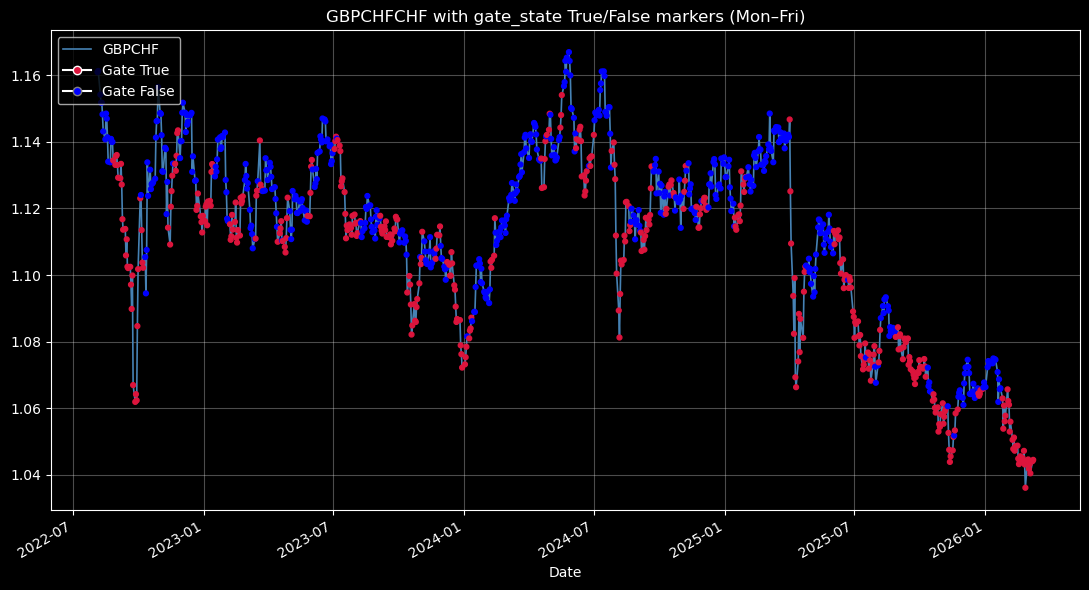

In [50]:

plt.style.use('dark_background')

TAIL_BARS = None
# Use Mon–Fri only for plotting to avoid weekend prints often present in FX feeds
# s=s.tail(200)
s_std_plot = functions2.standardize_fx_daily_index(s)

# Select tail for plotting
s_plot = s_std_plot.tail(TAIL_BARS) if TAIL_BARS else s_std_plot
fig, ax = plt.subplots(figsize=(11, 6))
# Base price plot
s_plot.plot(ax=ax, color='steelblue', lw=1.2, label=ticker)
# Align gate_state to price index (gate is Mon–Fri too)
g = gate_stateon.reindex(s_plot.index).fillna(False).astype(bool)
# print(f'gateon aligned to price (last 20 rows):\n{gate_stateon}')
# Overlay markers colored by gate_state state on the price series
colors = np.where(g.values, 'crimson', 'blue')
ax.scatter(s_plot.index, s_plot.values, c=colors, s=12, zorder=3)
# Legend: include price and gate_state state keys
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
gate_true = Line2D([0],[0], marker='o', color='w', label='Gate True', markerfacecolor='crimson', markersize=6)
gate_false = Line2D([0],[0], marker='o', color='w', label='Gate False', markerfacecolor='blue', markeredgecolor='gray', markersize=6)
ax.legend(handles + [gate_true, gate_false], labels + ['Gate True','Gate False'], loc='upper left')
ax.set_title(f'{ticker}CHF with gate_state True/False markers (Mon–Fri)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 ### Run sweep once a week/month

In [ ]:

import importlib
import scripts.sample_window_sweep as sws

# Ensure latest local module code is loaded in this kernel.
importlib.reload(fxshort_gates)

# --- Sweep mode ---
# "holdout"     : reserve the last OOS_HOLDOUT_MONTHS of the series as an untouched OOS
#                 test period. The sweep only sees data before the holdout cutoff.
#                 Use this for the initial validation run.
# "full_series" : sweep on the entire series. Use this AFTER OOS has passed, to get
#                 regime-current params for live use. Does NOT invalidate the prior OOS
#                 result — that validation already happened on genuinely unseen data.
SWEEP_MODE = "holdout"       # "holdout" | "full_series"
OOS_HOLDOUT_MONTHS = 6       # ignored in full_series mode

# Robustness mode: rolling monthly anchors + expanding windows per anchor.
USE_ROLLING_EXPANDING_WINDOWS = True
MIN_WINDOW_MONTHS = 12
ROLL_START_STEP_MONTHS = 3
MAX_WINDOWS = None  # Set int to limit runtime, e.g. 12

# Leaner sweep grid to reduce overfit risk and runtime.
SWEEP_SLOPE_WINDOWS = (6, 10, 15, 20)
SWEEP_CONSEC = (1, 2)
SWEEP_ENTRY_THR = (0.0, -1e-4)
SWEEP_EXIT_OFFSETS = (0.0, 1e-4)
SWEEP_RISES_KILL = (0,)
SWEEP_RISE_KILL_PCT = (0.0, 0.01, 0.015)
SWEEP_RISE_KILL_WINDOW = (3, 5)
SWEEP_GRACE_DAYS = (2,)

# Scale min_trades with window length for fair filtering across short/long windows.
TARGET_TRADES_PER_YEAR = 18
MIN_TRADES_FLOOR = 10
MIN_TRADES_CAP = 50

# Determine the series available for sweeping based on mode.
if SWEEP_MODE == "holdout":
    # Freeze the last OOS_HOLDOUT_MONTHS as an untouched holdout.
    # The sweep must not see any data from this period — even indirectly via
    # windows that extend into it — so we hard-cut the series here.
    holdout_cutoff = s.index[-1] - pd.DateOffset(months=OOS_HOLDOUT_MONTHS)
    # Snap to the nearest business day that is <= cutoff (avoids partial-month gaps).
    holdout_cutoff = s.index[s.index <= holdout_cutoff][-1]
    s_sweep = s.loc[:holdout_cutoff]
    print(f"SWEEP_MODE=holdout: sweeping up to {holdout_cutoff.date()} "
          f"({OOS_HOLDOUT_MONTHS}m holdout reserved from {(holdout_cutoff + pd.Timedelta(days=1)).date()} "
          f"to {s.index[-1].date()})")
else:
    # Post-OOS re-sweep on the full series to get regime-current params for live use.
    s_sweep = s
    print(f"SWEEP_MODE=full_series: sweeping full series {s.index[0].date()} to {s.index[-1].date()}")

start, end = functions2.get_window_dates(s_sweep)

if USE_ROLLING_EXPANDING_WINDOWS:
    windows = sws.rolling_expanding_month_windows(
        s_sweep.index,
        min_months=MIN_WINDOW_MONTHS,
        roll_start_step_months=ROLL_START_STEP_MONTHS,
    )
    if MAX_WINDOWS is not None:
        windows = windows[-MAX_WINDOWS:]
else:
    windows = [(start, end, None, 0)]

if not windows:
    raise ValueError("No windows generated for sweep.")

frames = []
trial_attempted = 0
trial_failed = 0
short_window_skipped = 0

for w_start, w_end, w_months, roll_seq in windows:
    s_win = s_sweep.loc[w_start:w_end]
    if len(s_win) < 60:
        short_window_skipped += 1
        continue

    months = int(w_months) if w_months is not None else max(1, int(round(len(s_win) / 21)))
    min_trades_win = int(round(TARGET_TRADES_PER_YEAR * months / 12.0))
    min_trades_win = max(MIN_TRADES_FLOOR, min(MIN_TRADES_CAP, min_trades_win))

    trial_attempted += 1
    df_win = fxshort_gates.sweep_fxshort_gate(
        ticker,
        price=s_win,
        gate_fn=fxshort_gates.fxshort_gate,
        slope_window_vals=SWEEP_SLOPE_WINDOWS,
        consec_vals=SWEEP_CONSEC,
        slope_entry_thr_vals=SWEEP_ENTRY_THR,
        slope_exit_thr_offsets=SWEEP_EXIT_OFFSETS,
        consec_rises_kill_vals=SWEEP_RISES_KILL,
        rise_kill_pct_vals=SWEEP_RISE_KILL_PCT,
        rise_kill_window_vals=SWEEP_RISE_KILL_WINDOW,
        buffer20_vals=(0.002,),
        max_combos=None,
        min_trades=min_trades_win,
        grace_days_vals=SWEEP_GRACE_DAYS,
        plot_top_gate=False,
        fee_per_trade=FEE_PER_TRADE,
        slippage_per_trade=SLIPPAGE_PER_TRADE,
        other_daily_fee_ann=OTHER_DAILY_FEE_ANN,
        carry_ann_vals=CARRY_ANN,
    )

    if df_win is None or len(df_win) == 0:
        trial_failed += 1
        continue

    df_win = df_win.copy()
    df_win["window_start"] = str(pd.Timestamp(w_start).date())
    df_win["window_end"] = str(pd.Timestamp(w_end).date())
    df_win["window_months"] = months
    df_win["roll_seq"] = int(roll_seq)
    df_win["min_trades_window"] = int(min_trades_win)
    frames.append(df_win)

if not frames:
    raise ValueError("Sweep returned no rows across generated windows; check parameters/window.")

results = pd.concat(frames, ignore_index=True)
results["run_id"] = run_meta["run_id"]
results["run_mode"] = run_meta["run_mode"]
results["created_utc"] = run_meta["created_utc"]
results["window_mode"] = "rolling_expanding" if USE_ROLLING_EXPANDING_WINDOWS else "single"
# Record sweep mode so the frozen-run cell and saved artifacts know whether a holdout
# was reserved and where the true OOS boundary sits.
results["sweep_mode"] = SWEEP_MODE
results["sweep_series_end"] = str(s_sweep.index[-1].date())

rank_col = "net_expectancy_per_trade" if "net_expectancy_per_trade" in results.columns else "total_pct_return"
results = results.sort_values(rank_col, ascending=False, kind="mergesort").reset_index(drop=True)

failed_pct = (100.0 * trial_failed / trial_attempted) if trial_attempted else 0.0

top = fxshort_gates.summarize_top(results, top=5)

fixed_input_cols = []
for c in ["carry_ann", "buffer20", "grace_days", "slope_source"]:
    if c in results.columns and results[c].nunique(dropna=False) == 1:
        fixed_input_cols.append(c)

if fixed_input_cols:
    fixed_inputs = {c: results[c].iloc[0] for c in fixed_input_cols}
    print("fixed inputs:", fixed_inputs)

varying_param_cols = []
for c in [
    "slope_window", "consec", "slope_entry_thr", "slope_exit_thr",
    "consec_rises_kill", "rise_kill_pct", "rise_kill_window",
    "window_months", "min_trades_window",
 ]:
    if c in top.columns and c in results.columns and results[c].nunique(dropna=False) > 1:
        varying_param_cols.append(c)

perf_cols = [
    "trades", "win_rate", "net_expectancy_per_trade", "total_pct_return",
    "avg_pct_return", "avg_win", "avg_loss", "median_holding_days",
    "max_draw_trade_pct", "best_trade_pct",
 ]
perf_cols = [c for c in perf_cols if c in top.columns]

show_cols = varying_param_cols + perf_cols
top_display = top[show_cols] if show_cols else top

print(ticker)
print(start.date(), end.date())
print("sweep_mode:", SWEEP_MODE)
print("window_mode:", results["window_mode"].iloc[0])
print("windows attempted:", trial_attempted)
print("windows failed (no valid config):", trial_failed, f"({failed_pct:.1f}%)")
print("windows skipped (too short):", short_window_skipped)
print("windows with results:", len(results[["window_start", "window_end"]].drop_duplicates()))
print(
    "min_trades_window range:",
    int(results["min_trades_window"].min()),
    "->",
    int(results["min_trades_window"].max()),
)
print('TOP 5 RESULTS:\n', top_display.to_string(index=False))
print("rows in sweep:", len(results))


fixed inputs: {'carry_ann': np.float64(0.053), 'buffer20': np.float64(0.002), 'grace_days': np.int64(2), 'slope_source': 'log_price'}
GBPCHF
2022-08-05 2026-03-10
window_mode: rolling_expanding
windows attempted: 187
windows failed (no valid config): 72 (38.5%)
windows skipped (too short): 0
windows with results: 115
min_trades_window range: 18 -> 50
TOP 5 RESULTS:
  consec  slope_entry_thr  slope_exit_thr  rise_kill_pct  rise_kill_window  trades  win_rate  net_expectancy_per_trade  total_pct_return  avg_pct_return  avg_win  avg_loss  median_holding_days  max_draw_trade_pct  best_trade_pct
      1          -0.0001         -0.0001          0.010               3.0      22  0.500000                  0.000670          0.060083        0.002731 0.013476 -0.008014                 11.5           -0.017615        0.039819
      1           0.0000          0.0000          0.015               3.0      18  0.500000                  0.000586          0.046608        0.002589 0.012812 -0.007633     

### Plot Best Sweep Result

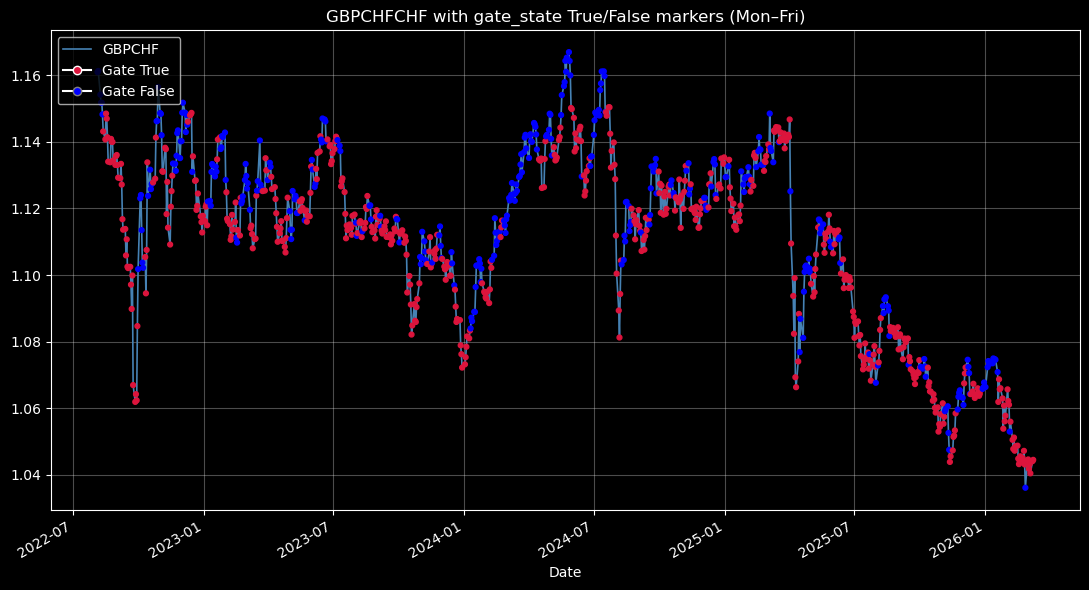

Plotted best sweep config: {'slope_window': 6, 'consec': 1, 'slope_entry_threshold': -0.0001, 'slope_exit_threshold': -0.0001, 'require_carry': True, 'consec_rises_kill': 0, 'rise_kill_pct': 0.01, 'rise_kill_window': 3, 'carry_ann': 0.053, 'buffer20': 0.002, 'grace_days': 2, 'min_run_days': 3, 'slope_source': 'log_price'}


In [7]:
# One plot only: use the top-ranked configuration after all windows are evaluated.
best_row = results.iloc[0]

best_cfg = {
    "slope_window": int(best_row["slope_window"]),
    "consec": int(best_row["consec"]),
    "slope_entry_threshold": float(best_row["slope_entry_thr"]),
    "slope_exit_threshold": float(best_row["slope_exit_thr"]),
    "require_carry": bool(best_row.get("require_carry", True)),
    "consec_rises_kill": int(best_row.get("consec_rises_kill", 0)),
    "rise_kill_pct": (
        float(best_row["rise_kill_pct"])
        if pd.notna(best_row.get("rise_kill_pct", np.nan))
        else None
    ),
    "rise_kill_window": (
        int(best_row["rise_kill_window"])
        if pd.notna(best_row.get("rise_kill_window", np.nan))
        else None
    ),
    "carry_ann": float(best_row.get("carry_ann", 0.04)),
    "buffer20": float(best_row.get("buffer20", 0.002)),
    "grace_days": int(best_row.get("grace_days", 2)),
    "min_run_days": 3,
    "slope_source": str(best_row.get("slope_source", "log_price")),
}

best_gate = fxshort_gates.fxshort_gate(
    s,
    shift_for_signal=True,
    **best_cfg,
 )

fxshort_gates.plot_gate_state(ticker, s, best_gate)
print("Plotted best sweep config:", best_cfg)

### save results

In [8]:
save_dir = pathlib.Path(".")
print("saving to directory:", save_dir.resolve())
save_dir.mkdir(parents=True, exist_ok=True)

results_to_save = results.copy()
float_cols = results_to_save.select_dtypes(include=["float64", "float32"]).columns
results_to_save[float_cols] = results_to_save[float_cols].round(6)

# Atomic write to run-specific full-results file + metadata sidecar for reproducibility.
run_csv = save_dir / f"sweep_results_{run_meta['run_id']}.csv"
tmp_csv = run_csv.with_suffix(".tmp")
results_to_save.to_csv(tmp_csv, index=False)
os.replace(tmp_csv, run_csv)

meta_path = save_dir / f"sweep_results_{run_meta['run_id']}.meta.json"
tmp_meta = meta_path.with_suffix(".tmp")
with open(tmp_meta, "w", encoding="utf-8") as f:
    json.dump(run_meta, f, indent=2, sort_keys=True)
os.replace(tmp_meta, meta_path)

# Also persist the single best config for direct reuse by the frozen-run cell.
best_saved_rank = "net_expectancy_per_trade" if "net_expectancy_per_trade" in results_to_save.columns else "total_pct_return"
best_saved_row = results_to_save.sort_values(best_saved_rank, ascending=False, kind="mergesort").iloc[0]
best_params = {
    "carry_ann": float(best_saved_row.get("carry_ann", CARRY_ANN)),
    "buffer20": float(best_saved_row.get("buffer20", 0.0)),
    "slope_window": int(best_saved_row["slope_window"]),
    "consec": int(best_saved_row["consec"]),
    "slope_entry_threshold": float(best_saved_row["slope_entry_thr"]),
    "slope_exit_threshold": float(best_saved_row["slope_exit_thr"]),
    "grace_days": int(best_saved_row.get("grace_days", 2)),
    "require_carry": bool(best_saved_row.get("require_carry", True)),
    "consec_rises_kill": int(best_saved_row.get("consec_rises_kill", 0)),
    "rise_kill_pct": (
        float(best_saved_row["rise_kill_pct"])
        if pd.notna(best_saved_row.get("rise_kill_pct", np.nan))
        else None
    ),
    "rise_kill_window": (
        int(best_saved_row["rise_kill_window"])
        if pd.notna(best_saved_row.get("rise_kill_window", np.nan))
        else None
    ),
    "min_run_days": 3,
    "slope_source": str(best_saved_row.get("slope_source", "log_price")),
    "source_run_id": str(run_meta["run_id"]),
    "source_rank_col": str(best_saved_rank),
}

best_json = save_dir / f"best_params_{run_meta['run_id']}.json"
tmp_best_json = best_json.with_suffix(".tmp")
with open(tmp_best_json, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2, sort_keys=True)
os.replace(tmp_best_json, best_json)

latest_best_json = save_dir / "best_params_latest.json"
tmp_latest_best_json = latest_best_json.with_suffix(".tmp")
with open(tmp_latest_best_json, "w", encoding="utf-8") as f:
    json.dump(best_params, f, indent=2, sort_keys=True)
os.replace(tmp_latest_best_json, latest_best_json)

print("saved full results:", run_csv)
print("saved metadata:", meta_path)
print("saved best params:", best_json)
print("updated latest best params:", latest_best_json)

saving to directory: /Users/alexwebb/laptop_coding/risk_matrix/fx_hedges
saved: sweep_results_e08ab9ff649c.csv
metadata: sweep_results_e08ab9ff649c.meta.json
